In [1]:
import numpy as np
from matplotlib import pyplot as plt

from loki.libloki.configs import PulsarSearchConfig
from loki.libloki.plans import FFAPlanBase
from loki.libloki.prune import EPMultiPassFourier
from pyloki.config import ParamLimits
from pyloki.detection import thresholding
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


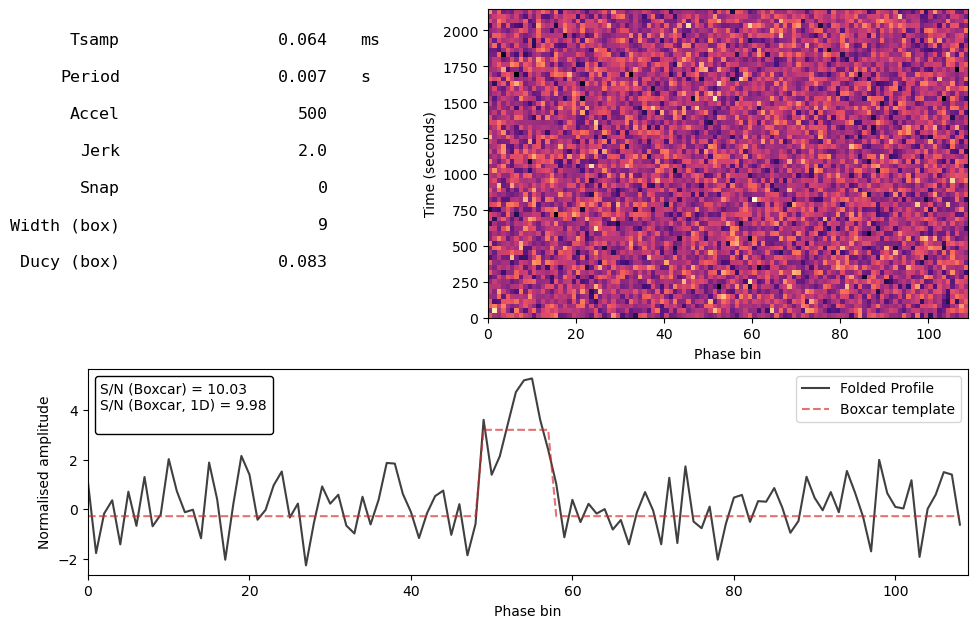

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 500
jerk = 2.0
nsamps = 2**25
mod_kwargs = {"acc": accel, "jerk": jerk}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=10.0,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_upper((142.0, 144.0), [jerk, accel], (-2.5, 2.5), cfg.tobs)
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 8192
bseg_ffa = cfg.nsamps // 128
search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=3,
    nthreads=4,
    ducy_max=0.5,
    wtsp=1.2,
    use_fourier=True,
)
plan = FFAPlanBase(search_cfg)
branching_pattern = plan.get_branching_pattern()
branching_pattern

Param limits: [[-2.50000000e+00  2.50000000e+00]
 [-2.18435456e+03  3.18435456e+03]
 [ 1.41063088e+02  1.44950108e+02]]


array([4.        , 9.        , 1.        , 2.08672736, 1.43765786,
       3.        , 1.        , 9.        , 1.        , 1.        ,
       3.        , 1.        , 1.        , 2.08672736, 1.43765786,
       3.        , 1.        , 3.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 3.        , 2.19549593,
       1.36621563, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.53003195, 1.96074337,
       1.00063898, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 2.0862069 , 1.43709826,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 1.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.00063898, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 2.12739464, 1.4101756 , 1.        , 1.     

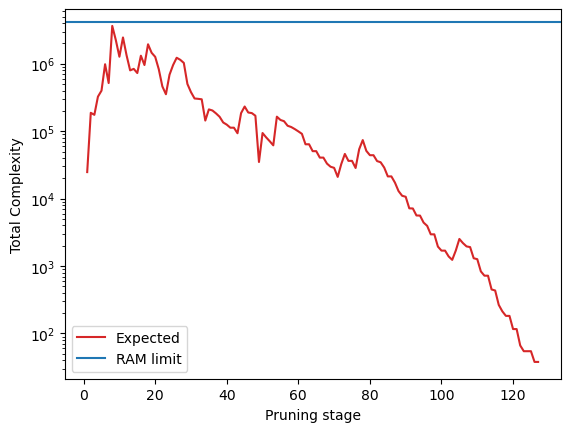

In [4]:
thresholds = np.array([1.9, 2.3, 2.2, 2.3, 2.4, 2.5, 2.9, 2.9, 3.1, 3.3, 3.4, 3.6, 3.7,
       3.9, 4. , 4.1, 4.1, 4.2, 4.2, 4.1, 4.3, 4.5, 4.5, 4.6, 4.7, 4.5,
       4.4, 4.4, 4.8, 4.8, 4.8, 4.5, 4.4, 5.1, 5.1, 4.9, 4.9, 4.9, 5. ,
       4.9, 4.9, 4.6, 4.9, 4.8, 4.9, 5. , 4.8, 4.9, 5.6, 5.5, 5.5, 5.5,
       5.5, 5.5, 5.5, 5.4, 5.5, 5.4, 5.4, 5.4, 5.4, 5.6, 4.9, 5.6, 5.2,
       5.6, 4.9, 5.6, 5.6, 5.5, 5.7, 5.8, 5.2, 5.8, 5.1, 5.8, 5.8, 5.3,
       5.9, 5.9, 5.4, 5.9, 5.8, 5.9, 6. , 5.3, 6. , 6.1, 6.1, 6. , 6.2,
       6. , 6.2, 6. , 6.2, 6.2, 6.3, 5.9, 6.4, 6.4, 5.8, 6.4, 6.4, 6.4,
       6.5, 6.5, 6.5, 6.4, 6.6, 6.5, 6.7, 6.7, 6.1, 6.8, 6.7, 6.9, 6.9,
       6.9, 6.3, 7. , 6.5, 7.1, 7.1, 6.4, 6.6, 7.1, 6.4])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=10.0,
    ducy_max=0.5,
    wtsp=1.2,
)
nparam_vol = plan.ncoords[-1]
x = np.arange(1, len(branching_pattern) + 1)
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**22, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [5]:
ep_manager = EPMultiPassFourier(
    search_cfg,
    thresholds,
    n_runs=16,
    max_sugg=2**22,
    batch_size=1024,
    poly_basis="taylor",
    show_progress=False,
)
ep_manager.execute(
    tim_data.ts_e,
    tim_data.ts_v,
    outdir="pruning_results/jerk_test/",
    file_prefix="test_jerk",
)

[2026-04-25 14:47:46.477] [info] EPMultiPass: Initializing with FFA
[2026-04-25 14:47:46.557] [info] P-FFA [8192, 1, 1, 33, 2, 33] -> [128, 1, 3, 2087, 2, 33]
[2026-04-25 14:47:46.557] [info] FFA Memory Usage: 0.79 GB + 0.00 GB (coords)
[2026-04-25 14:47:49.921] [info] Starting Pruning for 16 runs, with 4 threads
[2026-04-25 14:47:49.925] [info] Pruning run 004: Memory Usage: 2.41 GB (tree) + 0.02 GB (workspace)
[2026-04-25 14:47:49.925] [info] Pruning run 004: initialized
[2026-04-25 14:47:49.925] [info] Pruning run 012: Memory Usage: 2.41 GB (tree) + 0.02 GB (workspace)
[2026-04-25 14:47:49.925] [info] Pruning run 020: Memory Usage: 2.41 GB (tree) + 0.02 GB (workspace)
[2026-04-25 14:47:49.925] [info] Pruning run 028: Memory Usage: 2.41 GB (tree) + 0.02 GB (workspace)
[2026-04-25 14:47:49.925] [info] Pruning run 020: initialized
[2026-04-25 14:47:49.925] [info] Pruning run 012: initialized
[2026-04-25 14:47:49.925] [info] Pruning run 028: initialized
[2026-04-25 14:48:07.941] [info] 

In [6]:
result_file = "pruning_results/jerk_test/test_jerk_pruning_nstages_128_results.h5"
pgram = ScatteredPeriodogram.load(result_file)
print(f"True params, j: {cfg.mod_kwargs["jerk"]:.3f}, a: {cfg.mod_kwargs["acc"]:.3f}, f: {cfg.freq:.10f}")
print(pgram.get_summary_cands(10, score_type="score", run_id=None))

True params, j: 2.000, a: 500.000, f: 142.8571428571
Top candidates:
dparams: djerk: 0.0007595662426, daccel: 0.2038946555, dfreq: 2.299372669e-05
Run: 115_15, S/N (EP): 7.95, S/N: 9.41, jerk: 2.00020, accel: 499.95, freq: 142.857159
Run: 115_15, S/N (EP): 8.21, S/N: 9.22, jerk: 2.00020, accel: 499.95, freq: 142.857136
Run: 115_15, S/N (EP): 9.08, S/N: 8.47, jerk: 1.99945, accel: 499.89, freq: 142.857102
Run: 115_15, S/N (EP): 8.24, S/N: 8.46, jerk: 1.99945, accel: 499.89, freq: 142.857125
Run: 067_09, S/N (EP): 7.95, S/N: 7.94, jerk: -0.08155, accel: -546.15, freq: 143.724827
Run: 123_16, S/N (EP): 8.44, S/N: 7.93, jerk: 1.99957, accel: 499.83, freq: 142.857108
Run: 067_09, S/N (EP): 7.83, S/N: 7.92, jerk: -0.08155, accel: -546.15, freq: 143.724850
Run: 067_09, S/N (EP): 7.92, S/N: 7.91, jerk: -0.08155, accel: -545.94, freq: 143.724833
Run: 067_09, S/N (EP): 7.74, S/N: 7.88, jerk: -0.08155, accel: -545.94, freq: 143.724856
Run: 123_16, S/N (EP): 7.33, S/N: 7.87, jerk: 1.99957, accel: 

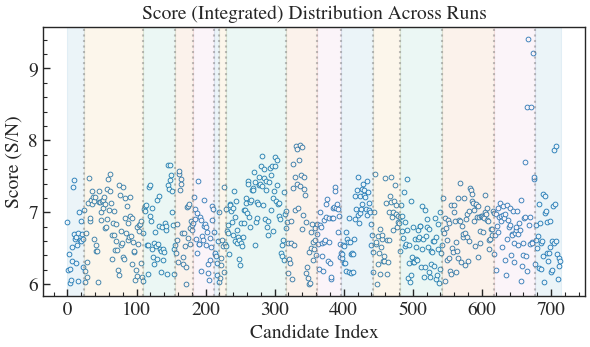

In [7]:
pgram.plot_scores(kind="scatter", run_id=None, snr_min=6)
plt.show()

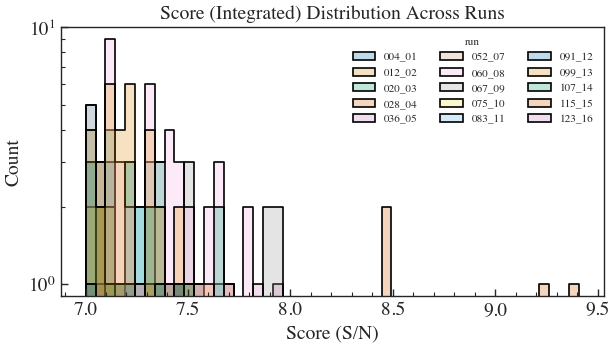

In [8]:
pgram.plot_scores(kind="hist", run_id=None, snr_min=7)
plt.show()

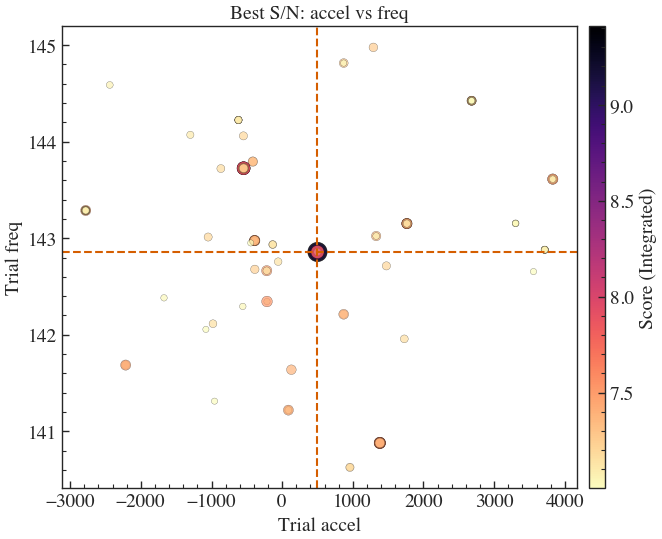

In [9]:
pgram.plot_correlation("accel", "freq", true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq}, run_id=None, snr_min=7)
plt.show()

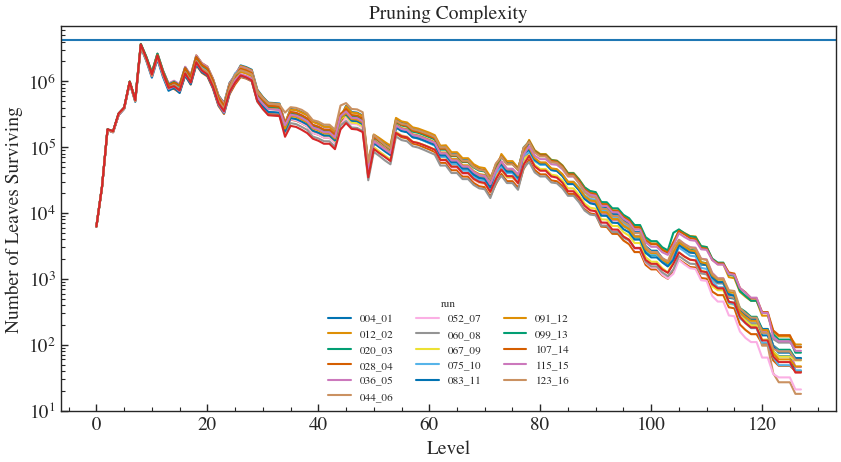

In [10]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(x, np.concatenate(([1], thresh_state.get_info("complexity"))) * nparam_vol, label="Expected", c="tab:red")
ax_list[0].axhline(2**22, label="RAM limit", c="tab:blue")
plt.show()